In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/10. Random Forests/Company_Data.csv')

In [4]:
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [5]:
df.shape

(400, 11)

In [6]:
df.isnull().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [7]:
df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


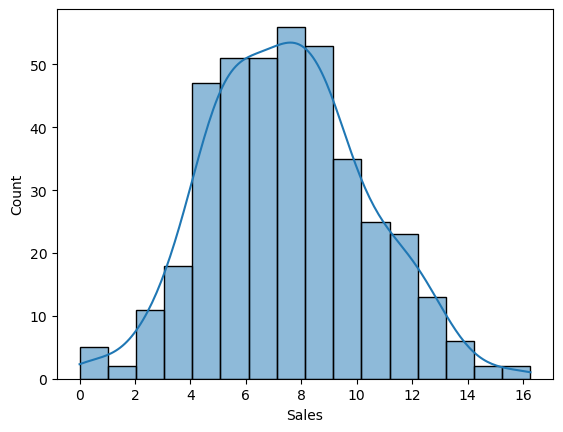

In [8]:
sns.histplot(df['Sales'], kde=True); plt.show()

In [9]:
df['Sales_Category'] = np.where(df['Sales'] > 8, 'High', 'Low')

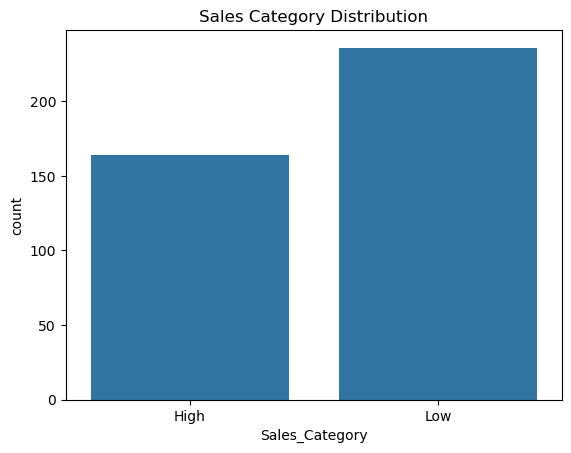

In [80]:
sns.countplot(x='Sales_Category', data=df)
plt.title("Sales Category Distribution")
plt.show()

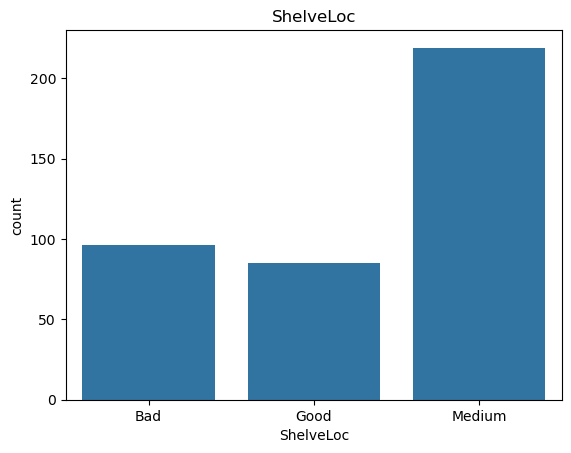

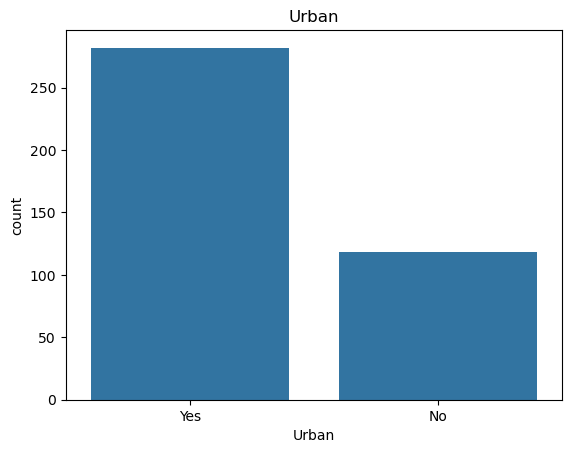

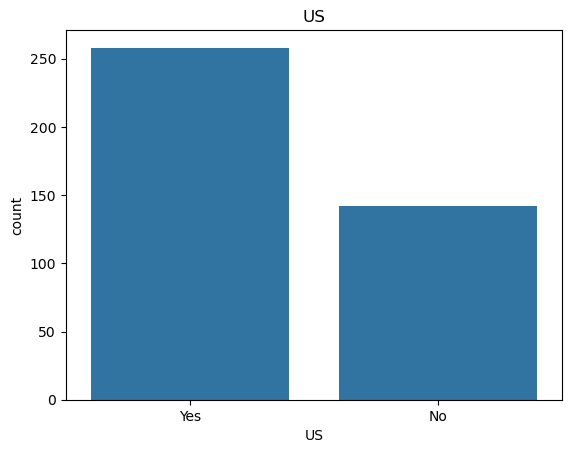

In [81]:
cat_cols = ['ShelveLoc', 'Urban', 'US']
for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

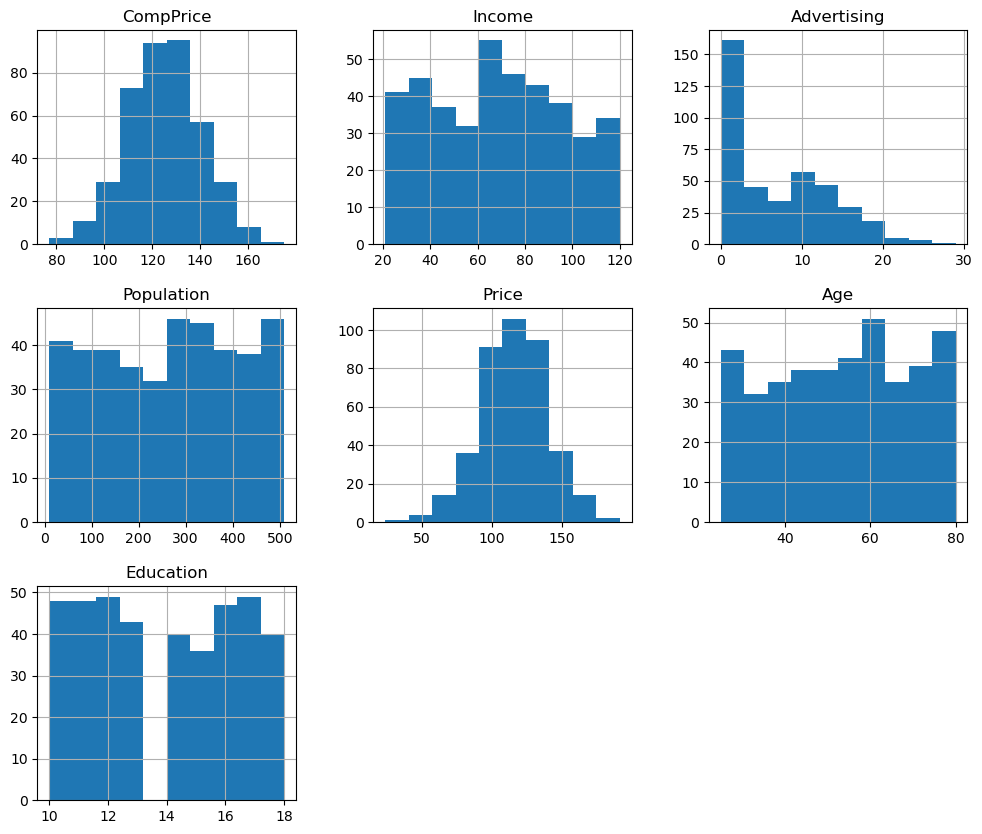

In [82]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(12,10))
plt.show()

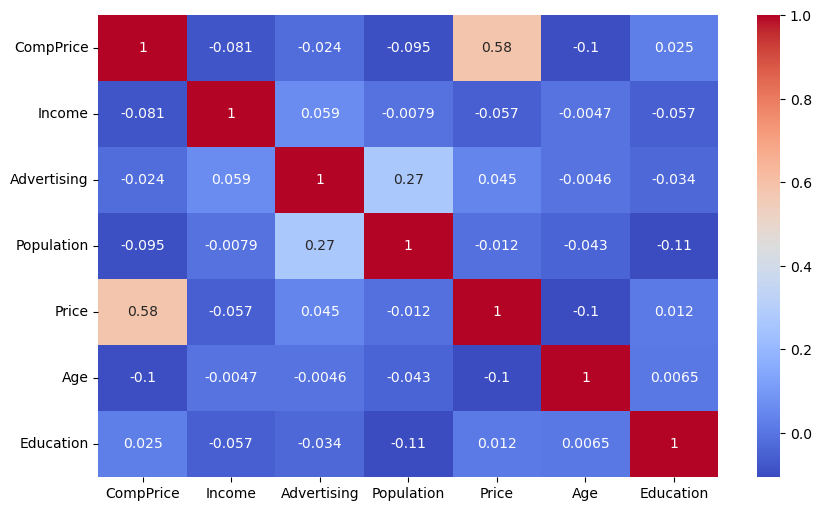

In [83]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [11]:
df = df.drop(columns=['Sales'], errors='ignore')
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Sales_Category_Low', axis=1)
y = df['Sales_Category_Low']


In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.20, random_state = 42, stratify=y)

In [13]:
rf_model = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,class_weight='balanced',n_jobs=-1)

rf_model.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_pred = rf_model.predict(X_test)

print("\n--------------MODEL PERFORMANCE-------------- ")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


--------------MODEL PERFORMANCE-------------- 
Accuracy: 0.8375

Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.64      0.76        33
        True       0.79      0.98      0.88        47

    accuracy                           0.84        80
   macro avg       0.87      0.81      0.82        80
weighted avg       0.86      0.84      0.83        80


Confusion Matrix:
 [[21 12]
 [ 1 46]]


In [15]:
importance = pd.Series(rf_model.feature_importances_, index = X.columns)
importance = importance.sort_values(ascending = False)

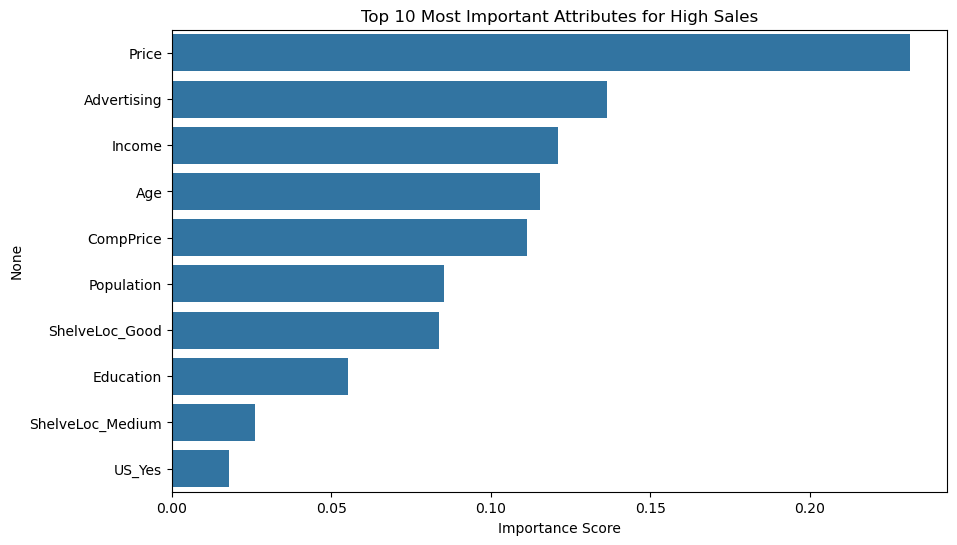


Top 10 Feature Importances:
 Price               0.231490
Advertising         0.136430
Income              0.121156
Age                 0.115503
CompPrice           0.111420
Population          0.085431
ShelveLoc_Good      0.083672
Education           0.055090
ShelveLoc_Medium    0.026018
US_Yes              0.017729
dtype: float64


In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importance[:10], y=importance[:10].index)
plt.title('Top 10 Most Important Attributes for High Sales')
plt.xlabel('Importance Score')
plt.show()
print("\nTop 10 Feature Importances:\n", importance.head(10))

# Business Interpretation
## 🔸1. Price (Highest Impact)
As price increases → sales decrease
Customers are price sensitive
Pricing strategy is critical
## 🔸 2. Advertising
Higher advertising → higher visibility → more sales
Strong driver of demand
## 🔸 3. Income
Areas with higher income → higher purchasing power
Premium pricing works better in such regions
## 🔸 4. Age
Different age groups → different buying behavior
Helps in targeted marketing
## 🔸 5. Competitor Price
If competitor price is higher → your product becomes more attractive
Shows competitive positioning matters

# Final Conclusion

The Random Forest model reveals that Price is the most critical factor influencing sales, followed by Advertising, Income, Age, and Competitor Price.
This suggests that pricing strategy and marketing efforts play a significant role in driving sales, while demographic and competitive factors also contribute to customer purchasing behavior.